In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/custom-dataset/README.roboflow.txt
/kaggle/input/custom-dataset/data.yaml
/kaggle/input/custom-dataset/valid/labels/roboflow_annotation_mp4-0044_jpg.rf.b1069c31b1dbcbba2509ac8815601732.txt
/kaggle/input/custom-dataset/valid/labels/roboflow_annotation_mp4-0032_jpg.rf.b11bb8f5d22ce4aa76ef818848adb6e6.txt
/kaggle/input/custom-dataset/valid/labels/roboflow_annotation_mp4-0014_jpg.rf.1578bdfb0ac4f160cc21e3bf5bc3d2ad.txt
/kaggle/input/custom-dataset/valid/images/roboflow_annotation_mp4-0014_jpg.rf.1578bdfb0ac4f160cc21e3bf5bc3d2ad.jpg
/kaggle/input/custom-dataset/valid/images/roboflow_annotation_mp4-0044_jpg.rf.b1069c31b1dbcbba2509ac8815601732.jpg
/kaggle/input/custom-dataset/valid/images/roboflow_annotation_mp4-0032_jpg.rf.b11bb8f5d22ce4aa76ef818848adb6e6.jpg
/kaggle/input/custom-dataset/test/labels/roboflow_annotation_mp4-0027_jpg.rf.58466ccf8cea7be425019bc0694f6fba.txt
/kaggle/input/custom-dataset/test/labels/roboflow_annotation_mp4-0023_jpg.rf.09d102bea38de36a239a0d0dcd83c6f

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.0 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found exi

In [3]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
model = YOLO('yolov8n.pt')

100%|██████████| 6.25M/6.25M [00:00<00:00, 82.7MB/s]


In [5]:
import os

dataset_path = '/kaggle/input/custom-dataset'
data_yaml_path = os.path.join(dataset_path, 'data.yaml')

if not os.path.exists(data_yaml_path):
    print(f"Error: data.yaml not found at {data_yaml_path}. Please check your dataset path.")
    raise FileNotFoundError(f"Data YAML file not found at {data_yaml_path}")

else:
    print(f"Data YAML file found at {data_yaml_path}")

Data YAML file found at /kaggle/input/custom-dataset/data.yaml


In [6]:
results = model.train(
    data = data_yaml_path,
    epochs=50,
    imgsz=640,
)

Ultralytics 8.3.152 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/custom-dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, 

100%|██████████| 755k/755k [00:00<00:00, 16.9MB/s]


Overriding model.yaml nc=80 with nc=5

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 64.9MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.7±0.6 ms, read: 8.5±5.3 MB/s, size: 47.6 KB)


...

      50/50      2.87G     0.4458      1.036     0.9704         12        640: 100%|██████████| 6/6 [00:00<00:00,  7.35it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 17.64it/s]

                   all          3          3      0.968          1      0.995      0.796



50 epochs completed in 0.017 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.152 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 30.74it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all          3          3       0.94          1      0.995      0.871
                  Book          2          2      0.989          1      0.995      0.846
                Helmet          1          1      0.891          1      0.995      0.895
Speed: 0.2ms preprocess, 3.7ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs/detect/train


In [7]:
metrics = model.val()
print("Validation/Test Metrics:", metrics.results_dict)

Ultralytics 8.3.152 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 82.2±62.9 MB/s, size: 37.3 KB)


val: Scanning /kaggle/input/custom-dataset/valid/labels... 3 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3/3 [00:00<00:00, 822.20it/s]

WARNING ⚠️ val: Cache directory /kaggle/input/custom-dataset/valid is not writeable, cache not saved.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 10.61it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all          3          3       0.94          1      0.995      0.871
                  Book          2          2      0.989          1      0.995      0.846
                Helmet          1          1      0.891          1      0.995      0.895
Speed: 0.5ms preprocess, 17.4ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to runs/detect/train2
Validation/Test Metrics: {'metrics/precision(B)': 0.9400278249171004, 'metrics/recall(B)': 1.0, 'metrics/mAP50(B)': 0.995, 'metrics/mAP50-95(B)': 0.8705526859504132, 'fitness': 0.882997417355372}


In [ ]:
model_new = YOLO('/kaggle/working/yolo11n.pt')

results = model('/kaggle/input/custom-dataset/test/images/roboflow_annotation_mp4-0023_jpg.rf.09d102bea38de36a239a0d0dcd83c6f4.jpg')

for result in results:
    xywh = result.boxes.xywh
    xywhn = result.boxes.xywhn
    xyxy = result.boxes.xyxy
    xyxyn = result.boxes.xyxyn
    names = [result.names[cls.item()] for cls in result.boxes.cls.int()]
    confs = result.boxes.conf


image 1/1 /kaggle/input/custom-dataset/test/images/roboflow_annotation_mp4-0023_jpg.rf.09d102bea38de36a239a0d0dcd83c6f4.jpg: 640x640 1 Book, 1 Dumbbell, 7.6ms
Speed: 1.8ms preprocess, 7.6ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)


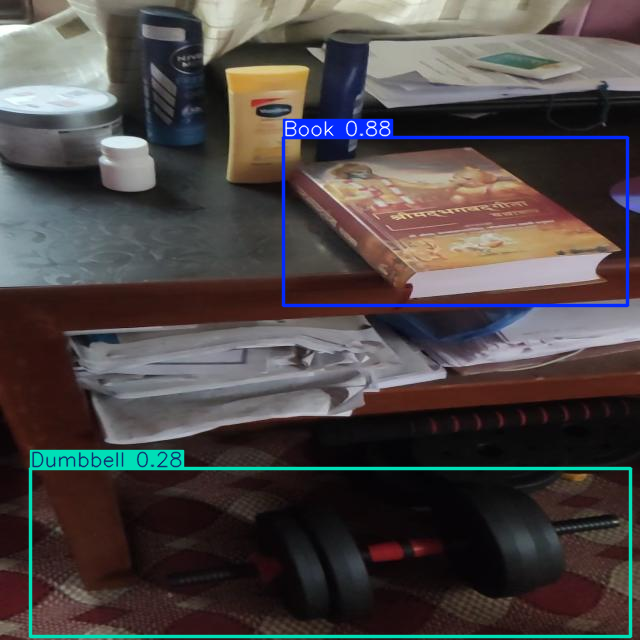

In [8]:
model_new = YOLO('/kaggle/working/yolo11n.pt')

results = model('/kaggle/input/custom-dataset/test/images/roboflow_annotation_mp4-0023_jpg.rf.09d102bea38de36a239a0d0dcd83c6f4.jpg')

for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    keypoints = result.keypoints  # Keypoints object for pose outputs
    probs = result.probs  # Probs object for classification outputs
    obb = result.obb  # Oriented boxes object for OBB outputs
    result.show()  # display to screen
    result.save(filename="result.jpg")  